# 02 — RFM Scoring + K-Means Clustering

We load the RFM scores produced by the SQL pipeline and apply K-Means clustering
to validate that the quintile-based segments correspond to real behavioral groups in the data.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
con = duckdb.connect('../data/retail.duckdb')
scores = con.execute('SELECT * FROM rfm_scores').df()
con.close()

print(f'Shape: {scores.shape}')
scores.head()

Shape: (5878, 8)


,Customer ID,frequency,monetary,recency,r_score,f_score,m_score,rfm_score
0,14095,1,2.95,722,1,1,1,3
1,13788,1,3.75,504,1,1,1,3
2,16738,1,3.75,297,2,1,1,4
3,14792,1,6.20,63,3,2,1,6
4,15913,1,6.30,533,1,1,1,3


## Normalize features

K-Means uses Euclidean distance, so features on different scales (days vs £) would make
monetary dominate the clustering. StandardScaler puts all three on the same scale.

In [3]:
features = scores[['recency', 'frequency', 'monetary']]
scaler = StandardScaler()
X = scaler.fit_transform(features)

## Elbow method — finding optimal K

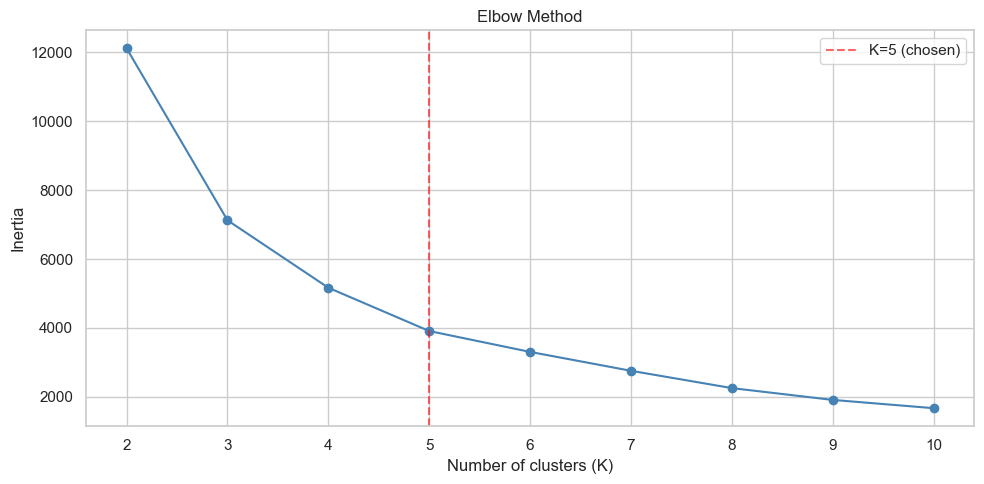

In [4]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(K_range, inertias, marker='o', color='steelblue')
ax.axvline(x=5, color='red', linestyle='--', alpha=0.6, label='K=5 (chosen)')
ax.set_title('Elbow Method')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/elbow_method.png', dpi=150)
plt.show()

## Silhouette Score — cluster separation quality

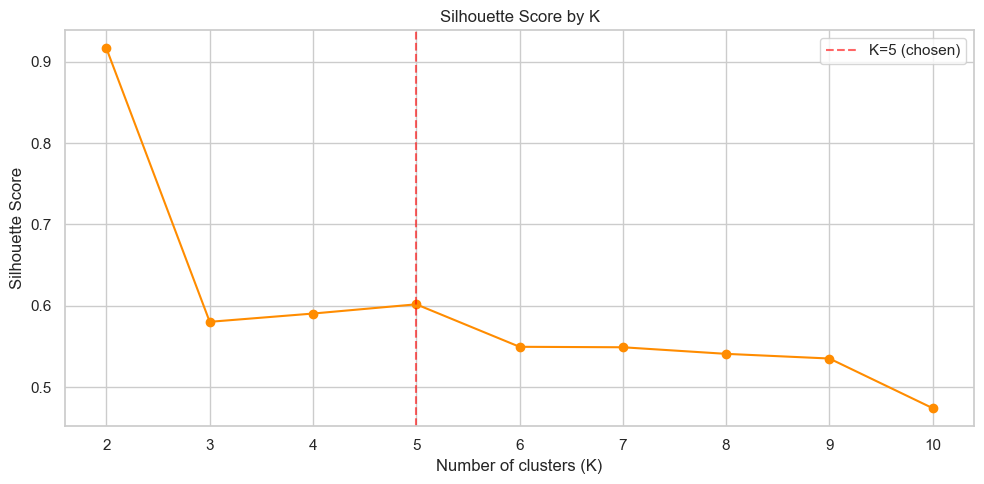

Silhouette Score at K=5: 0.602


In [5]:
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    silhouettes.append(silhouette_score(X, labels))

fig, ax = plt.subplots()
ax.plot(K_range, silhouettes, marker='o', color='darkorange')
ax.axvline(x=5, color='red', linestyle='--', alpha=0.6, label='K=5 (chosen)')
ax.set_title('Silhouette Score by K')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/silhouette_scores.png', dpi=150)
plt.show()

k5_idx = list(K_range).index(5)
print(f'Silhouette Score at K=5: {silhouettes[k5_idx]:.3f}')

## Final clustering at K=5

In [6]:
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
scores['cluster'] = km5.fit_predict(X)

print('Cluster sizes:')
print(scores['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0     367
1    1925
2    3558
3       4
4      24
Name: count, dtype: int64


## Cluster profiles — do they align with RFM segments?

In [7]:
profile = (
    scores.groupby('cluster')[['recency', 'frequency', 'monetary', 'rfm_score']]
    .mean()
    .round(1)
    .sort_values('rfm_score', ascending=False)
)
print('Cluster mean profiles:')
profile

Cluster mean profiles:


,recency,frequency,monetary,rfm_score
cluster,,,,
3,2.5,212.5,436835.8,15.0
4,21.5,119.8,100927.0,14.7
0,26.4,29.0,14228.8,14.5
2,74.1,5.2,1938.9,10.4
1,469.4,2.2,754.9,5.3


## Scatter — Recency vs Monetary, colored by cluster

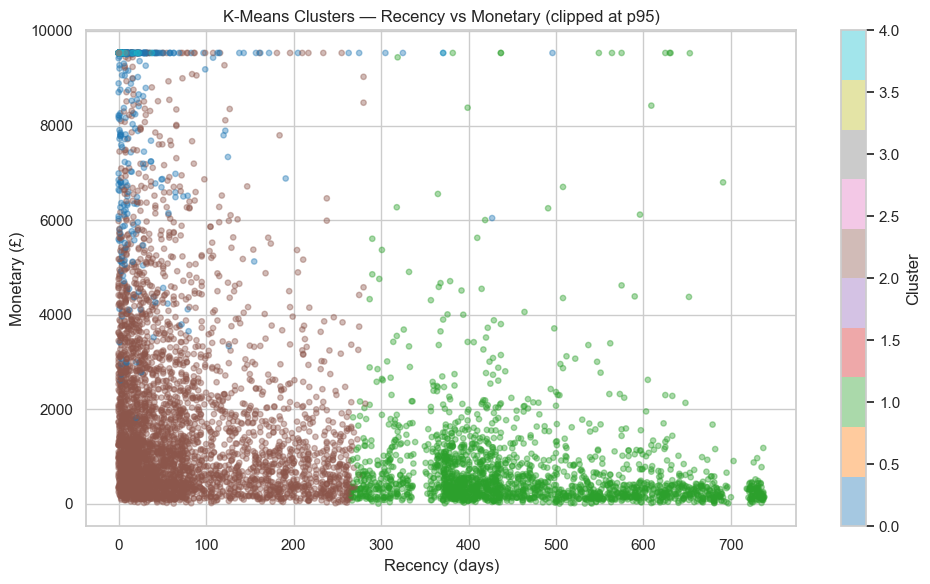

In [8]:
plot_df = scores.copy()
plot_df['monetary_clipped'] = plot_df['monetary'].clip(upper=plot_df['monetary'].quantile(0.95))

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    plot_df['recency'],
    plot_df['monetary_clipped'],
    c=plot_df['cluster'],
    cmap='tab10',
    alpha=0.4,
    s=15
)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title('K-Means Clusters — Recency vs Monetary (clipped at p95)')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Monetary (£)')
plt.tight_layout()
plt.savefig('../outputs/clusters_scatter.png', dpi=150)
plt.show()